# Monitor an RL training run

Reads the TensorBoard event files under `runs/<experiment_name>/` and renders the
training, loss, and CRN-eval curves inline. Equivalent to opening TensorBoard
(`uv run tensorboard --logdir runs/`) but works offline and lets you slice the
data programmatically.

**What you get:**

1. List of every scalar tag in the event file.
2. Training curves: `train/episodic_return`, `train/episodic_length`, `charts/SPS`, `charts/learning_rate`.
3. PPO loss panel: `losses/value_loss`, `losses/policy_loss`, `losses/entropy`, `losses/approx_kl`, `losses/clipfrac`.
4. CRN evaluation: `eval/rl_return` vs `eval/baseline_return`, `eval/paired_uplift`, `eval/win_rate`.
5. Business KPIs (RL vs Baseline): service level, stockout rate, turnover, mean price % of MSRP, revenue, net profit.
6. Latest-value snapshot table.
7. Checkpoint listing under `runs/<experiment_name>/checkpoints/`.

**Headline metric:** `eval/paired_uplift` is the per-seed mean of `(RL return − baseline return)` on the held-out CRN seed set. Positive *and stable* means the policy beats `BaselinePolicy` on bit-identical worlds — not on lucky draws. See [docs/adr/0004-rl-training-env.md](../docs/adr/0004-rl-training-env.md).

In [1]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Pick an experiment

`RUNS_ROOT` mirrors `--tb-log-dir` / `--checkpoint-dir` (default `runs/`). `EXPERIMENT` mirrors `--experiment-name` (default `rl_ppo`).

In [3]:
RUNS_ROOT = Path('runs')
EXPERIMENT = 'fashion_run'

EXP_DIR = RUNS_ROOT / EXPERIMENT
assert EXP_DIR.exists(), f'experiment dir not found: {EXP_DIR}. Run `uv run python -m src.rl.train --experiment-name {EXPERIMENT} ...` first.'

print(f'Experiment directory: {EXP_DIR}')
print('Event files:')
for p in sorted(EXP_DIR.glob('events.out.tfevents.*')):
    size_kb = p.stat().st_size / 1024.0
    print(f'  {p.name}  ({size_kb:.1f} KB)')
print(f'\nOther runs available under {RUNS_ROOT}:')
for d in sorted(RUNS_ROOT.iterdir()):
    if d.is_dir():
        print(f'  {d.name}')

Experiment directory: runs/fashion_run
Event files:
  events.out.tfevents.1778622494.Mislavs-MacBook-Pro.local.58694.0  (472.5 KB)

Other runs available under runs:
  fashion_run


## 2. Load every scalar tag

`EventAccumulator` is the same reader TensorBoard uses internally. `size_guidance={'scalars': 0}` disables downsampling so every recorded point comes through.

In [4]:
acc = EventAccumulator(str(EXP_DIR), size_guidance={'scalars': 0})
acc.Reload()

scalar_tags = sorted(acc.Tags().get('scalars', []))
print(f'Found {len(scalar_tags)} scalar tags:')
for t in scalar_tags:
    print(f'  {t}')

Found 25 scalar tags:
  charts/SPS
  charts/learning_rate
  eval/baseline_inventory_turnover
  eval/baseline_mean_price_pct_of_msrp
  eval/baseline_net_profit
  eval/baseline_return
  eval/baseline_revenue
  eval/baseline_service_level
  eval/baseline_stockout_rate
  eval/paired_uplift
  eval/rl_inventory_turnover
  eval/rl_mean_price_pct_of_msrp
  eval/rl_net_profit
  eval/rl_return
  eval/rl_revenue
  eval/rl_service_level
  eval/rl_stockout_rate
  eval/win_rate
  losses/approx_kl
  losses/clipfrac
  losses/entropy
  losses/policy_loss
  losses/value_loss
  train/episodic_length
  train/episodic_return


In [6]:
def scalar_series(tag: str) -> pd.DataFrame:
    """Return a DataFrame with columns ['step', 'value'] for one scalar tag, or empty if absent."""
    if tag not in scalar_tags:
        return pd.DataFrame({'step': [], 'value': []})
    events = acc.Scalars(tag)
    return pd.DataFrame({
        'step': [e.step for e in events],
        'value': [e.value for e in events],
    })

def plot_tags(tags, ylabel='', title='', logy=False, ax=None):
    """Plot one or more scalar tags on the same axis vs global_step."""
    if ax is None:
        _, ax = plt.subplots()
    for tag in tags:
        df = scalar_series(tag)
        if df.empty:
            continue
        ax.plot(df['step'], df['value'], label=tag, marker='o', markersize=3, linewidth=1.2)
    if logy:
        ax.set_yscale('symlog')
    ax.set_xlabel('env step')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    if len(tags) > 1:
        ax.legend(fontsize=8, loc='best')
    return ax

## 3. Training curves

`train/episodic_return` is the mean return over episodes that *completed* during the most recent rollout. Sparse early on (few episodes finished yet) and densifies as training progresses. The reward equals the per-tick balance delta, so `episodic_return` is the same currency as `eval/rl_net_profit`.

`train/episodic_length` should track `--episode-length` (default 180). `charts/SPS` is throughput; `charts/learning_rate` is the linearly annealed Adam LR.

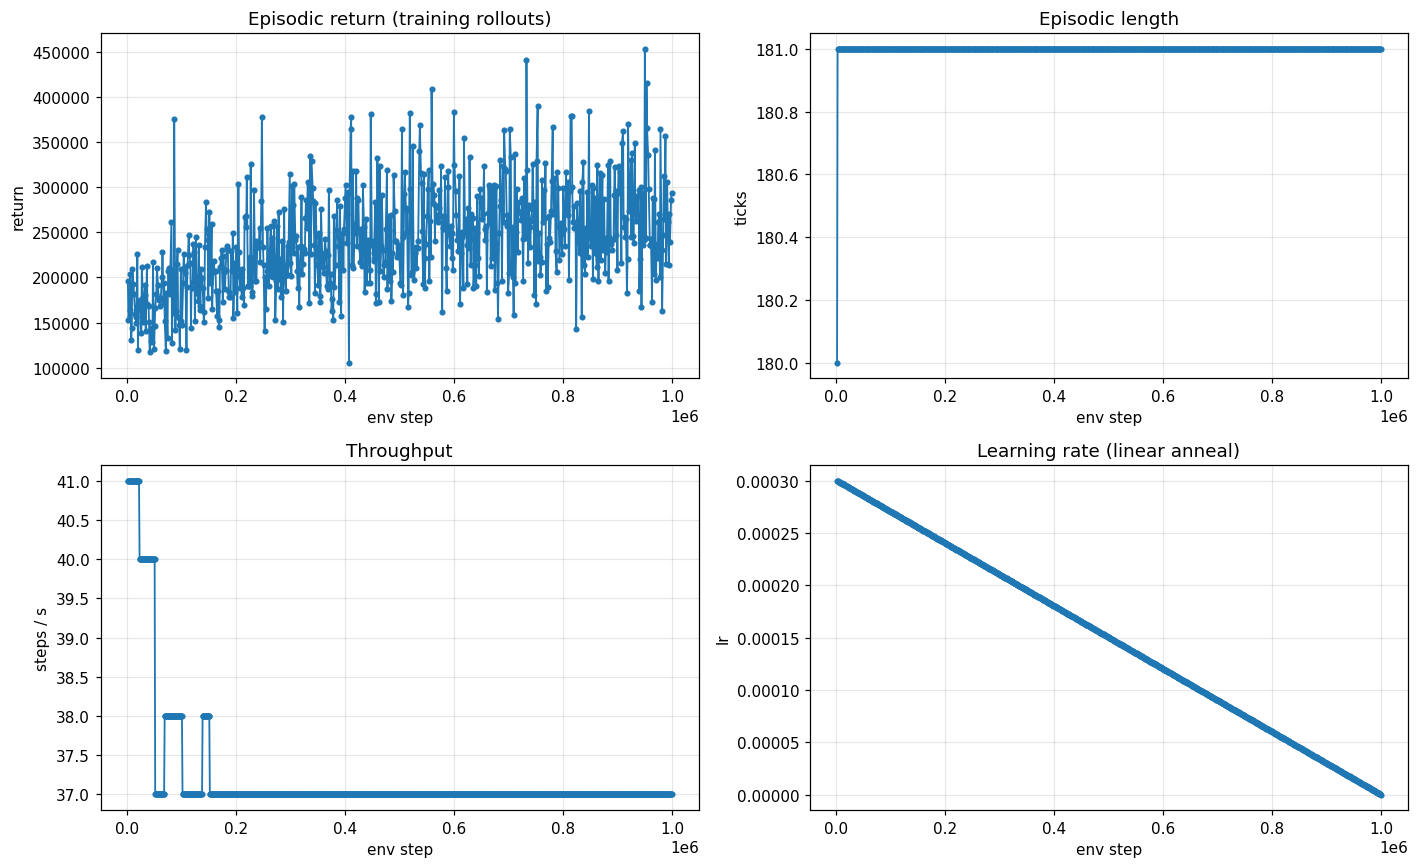

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_tags(['train/episodic_return'], ylabel='return', title='Episodic return (training rollouts)', ax=axes[0, 0])
plot_tags(['train/episodic_length'], ylabel='ticks', title='Episodic length', ax=axes[0, 1])
plot_tags(['charts/SPS'], ylabel='steps / s', title='Throughput', ax=axes[1, 0])
plot_tags(['charts/learning_rate'], ylabel='lr', title='Learning rate (linear anneal)', ax=axes[1, 1])
plt.tight_layout()
plt.show()

## 4. PPO loss panel

What healthy curves look like:

- `value_loss` — trends down as the critic fits returns better; can rise temporarily after large policy updates.
- `policy_loss` — noisy around 0; sign isn't meaningful in isolation.
- `entropy` — slowly decreases as the policy sharpens. Falling too fast → policy collapsing prematurely.
- `approx_kl` — should stay well below `--target-kl` (default off / unbounded); spikes signal big update steps.
- `clipfrac` — fraction of samples where the surrogate ratio was clipped. Healthy range is roughly 0.05–0.30; if it pins near 1.0 your LR / clip-coef is too aggressive.

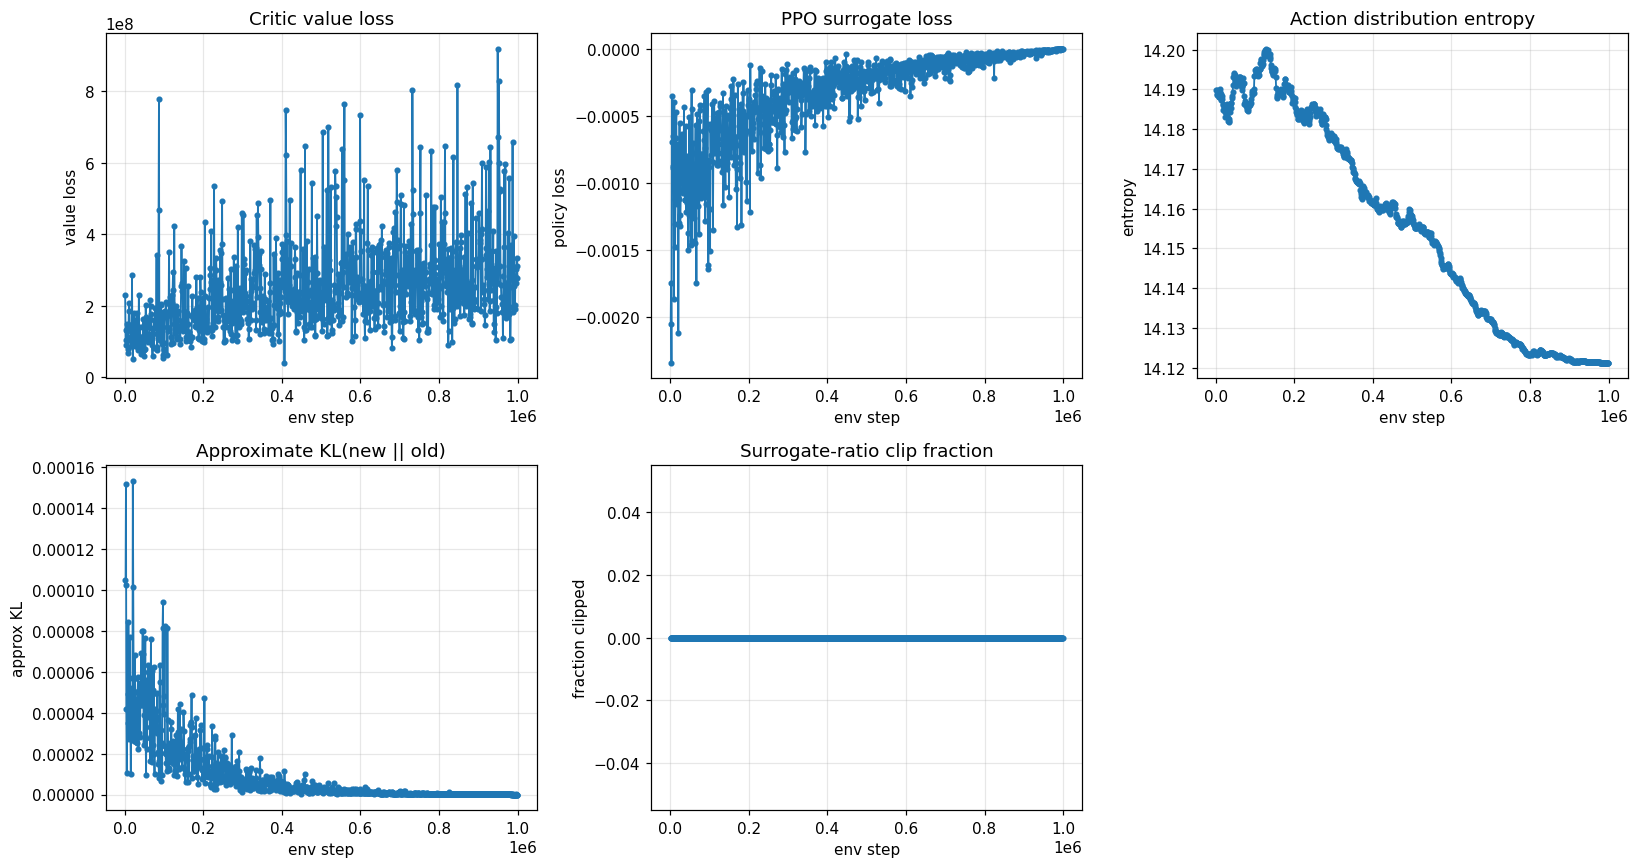

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_tags(['losses/value_loss'], ylabel='value loss', title='Critic value loss', ax=axes[0, 0])
plot_tags(['losses/policy_loss'], ylabel='policy loss', title='PPO surrogate loss', ax=axes[0, 1])
plot_tags(['losses/entropy'], ylabel='entropy', title='Action distribution entropy', ax=axes[0, 2])
plot_tags(['losses/approx_kl'], ylabel='approx KL', title='Approximate KL(new || old)', ax=axes[1, 0])
plot_tags(['losses/clipfrac'], ylabel='fraction clipped', title='Surrogate-ratio clip fraction', ax=axes[1, 1])
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## 5. CRN-paired evaluation

These scalars only appear if you trained with `--eval` enabled (default). They are produced by `evaluate(...)` in `src/rl/eval.py` and use a fixed held-out set of `--n-eval-seeds` (default 32) CRN seeds disjoint from training.

- **Top-left:** `eval/rl_return` vs `eval/baseline_return` — overlapping curves means the policy hasn't learned to beat baseline yet; an opening gap is what you want.
- **Top-right:** `eval/paired_uplift = mean_i(RL_i − Baseline_i)`. Because the pair shares `(world_seed, init_seed, capacity, balance, active subset, slot permutation)`, this cancels world variance completely.
- **Bottom-left:** `eval/win_rate` — fraction of seeds where RL ≥ baseline. > 0.5 means RL wins more often than not.
- **Bottom-right:** zoomed paired uplift around 0 with a reference line.

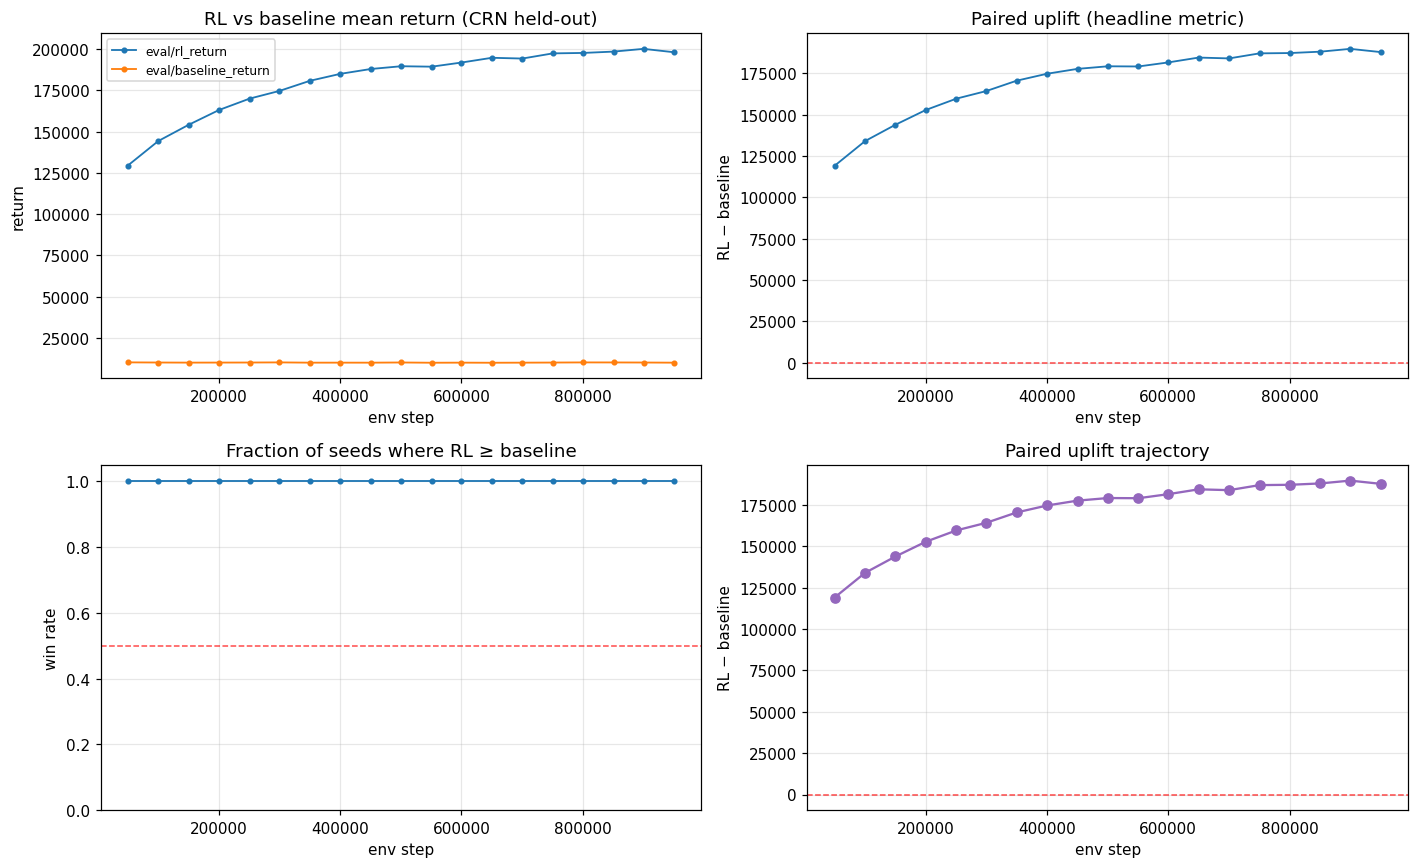

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_tags(['eval/rl_return', 'eval/baseline_return'], ylabel='return', title='RL vs baseline mean return (CRN held-out)', ax=axes[0, 0])

plot_tags(['eval/paired_uplift'], ylabel='RL − baseline', title='Paired uplift (headline metric)', ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plot_tags(['eval/win_rate'], ylabel='win rate', title='Fraction of seeds where RL ≥ baseline', ax=axes[1, 0])
axes[1, 0].axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1, 0].set_ylim(0, 1.05)

uplift = scalar_series('eval/paired_uplift')
if not uplift.empty:
    axes[1, 1].plot(uplift['step'], uplift['value'], marker='o', color='tab:purple')
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[1, 1].set_title('Paired uplift trajectory')
    axes[1, 1].set_xlabel('env step')
    axes[1, 1].set_ylabel('RL − baseline')
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 6. Business KPIs — RL vs Baseline (over training)

The same six metrics surfaced by `aggregate_episode(...)` in `src/rl/metrics.py`. Each pair lets you see *how* the policy beats (or loses to) baseline:

- **service_level** = sum(sales) / sum(demand). Higher is better.
- **stockout_rate** = fraction of (active SKU, tick) pairs with zero on-hand inventory. Lower is better.
- **inventory_turnover** = sum(sales) / mean(inventory). Higher is better (faster moving stock).
- **mean_price_pct_of_msrp** — pricing position. Higher = closer to MSRP, lower = persistent discounting.
- **revenue** and **net_profit** — currency.

`net_profit` is the same quantity as the training reward (sum of per-tick balance deltas), so it should track `eval/rl_return` closely.

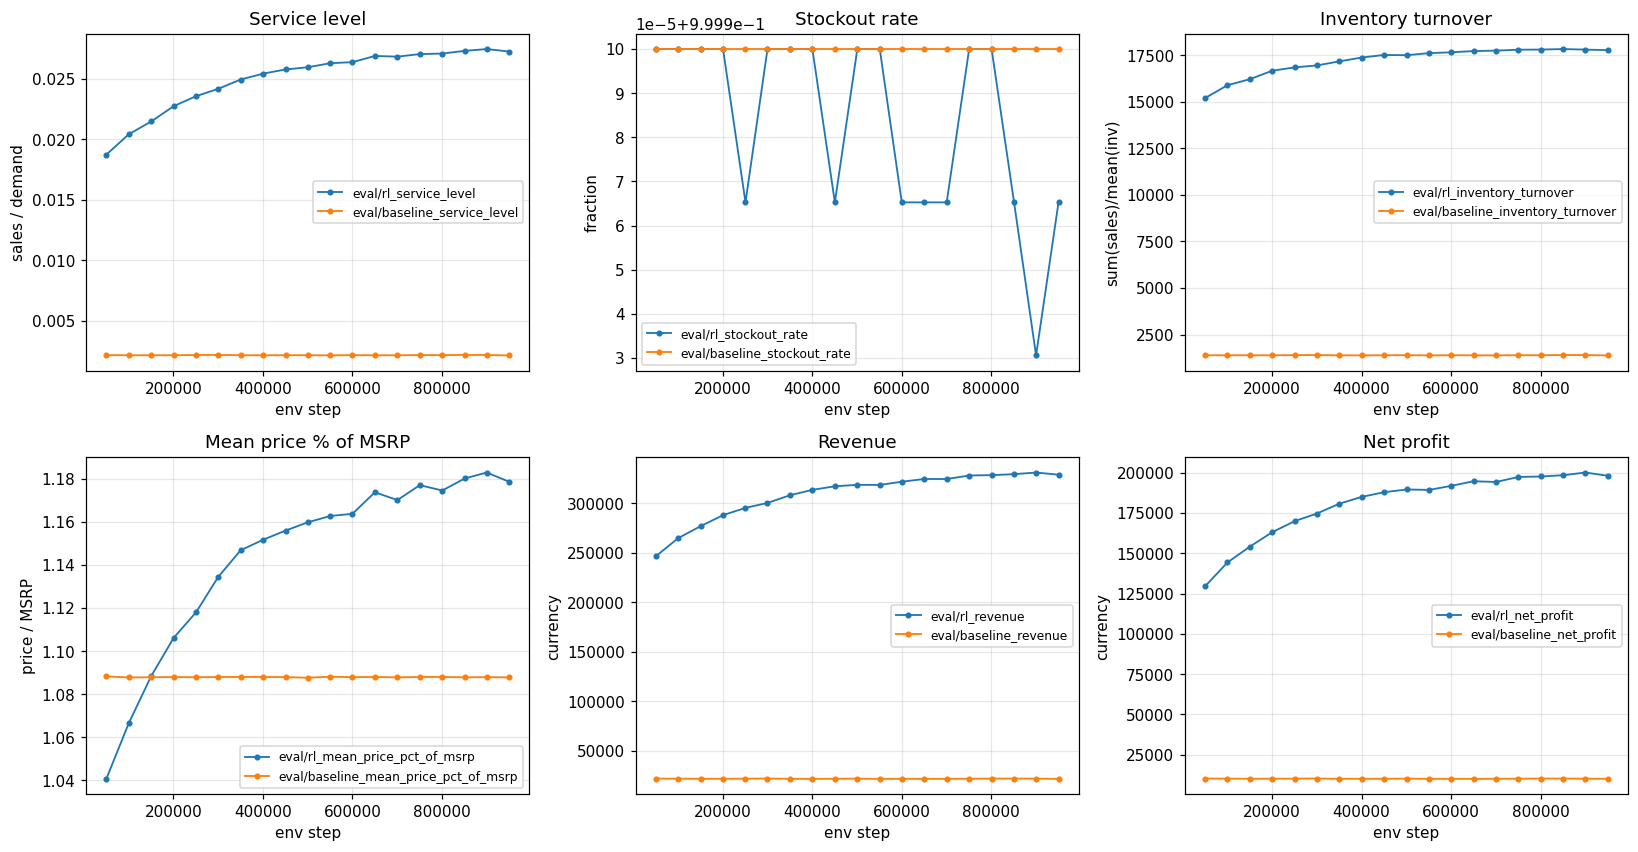

In [10]:
kpi_pairs = [
    ('service_level',          'Service level',         'sales / demand'),
    ('stockout_rate',          'Stockout rate',         'fraction'),
    ('inventory_turnover',     'Inventory turnover',    'sum(sales)/mean(inv)'),
    ('mean_price_pct_of_msrp', 'Mean price % of MSRP',  'price / MSRP'),
    ('revenue',                'Revenue',               'currency'),
    ('net_profit',             'Net profit',            'currency'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (kpi, title, ylabel) in zip(axes.flat, kpi_pairs):
    plot_tags([f'eval/rl_{kpi}', f'eval/baseline_{kpi}'], ylabel=ylabel, title=title, ax=ax)
plt.tight_layout()
plt.show()

## 7. Latest-value snapshot

One row per scalar tag with its most recent value — useful as a quick text summary if you only want to glance at the end-of-training state.

In [11]:
rows = []
for tag in scalar_tags:
    df = scalar_series(tag)
    if df.empty:
        continue
    rows.append({
        'tag': tag,
        'last_step': int(df['step'].iloc[-1]),
        'last_value': float(df['value'].iloc[-1]),
        'n_points': len(df),
    })
latest = pd.DataFrame(rows).set_index('tag').sort_index()
latest

,last_step,last_value,n_points
tag,,,
charts/SPS,999424,3.700000e+01,976
charts/learning_rate,999424,3.073770e-07,976
eval/baseline_inventory_turnover,950272,1.377906e+03,19
eval/baseline_mean_price_pct_of_msrp,950272,1.087812e+00,19
eval/baseline_net_profit,950272,1.012029e+04,19
eval/baseline_return,950272,1.012029e+04,19
eval/baseline_revenue,950272,2.144832e+04,19
eval/baseline_service_level,950272,2.159058e-03,19
eval/baseline_stockout_rate,950272,1.000000e+00,19


## 8. Checkpoint listing

Saved actors under `runs/<experiment_name>/checkpoints/`. The integer in the filename is the eval-call index (not the global env step); the final entry is `actor_step{total_env_steps:010d}.pt` written after the training loop returns.

To load one, see the snippet in the README (`Reinforcement Learning (PPO) → Checkpoints`).

In [12]:
ckpt_dir = EXP_DIR / 'checkpoints'
if not ckpt_dir.exists():
    print(f'No checkpoints found under {ckpt_dir}. Train with eval enabled (default) to produce them.')
else:
    rows = []
    for p in sorted(ckpt_dir.glob('actor_step*.pt')):
        rows.append({
            'file': p.name,
            'size_kb': p.stat().st_size / 1024.0,
        })
    pd.DataFrame(rows)